### MicroGrad Demo（面向自学的默会知识版）

本 Notebook 不只是“看懂代码”，而是按 Michael Polanyi 的默会知识理论来学：
- 我们知道的，往往多于我们能直接说清的（We know more than we can tell）。
- 所以学习重点不只是概念，还包括通过反复操作形成“手感”。

自学路线（每个代码单元都按这 4 步）：
1. 先预测：运行前先写下你认为会发生什么。
2. 再执行：观察输出与预测差异。
3. 做微改动：一次只改一个超参数或一行逻辑。
4. 复盘迁移：总结“这次学到的直觉”并迁移到下一格。

建议你在每个单元后都写 2 句学习日志：
- 显性知识：我能清楚说出的规则是什么？
- 默会知识：我刚刚形成了什么“感觉/判断力”？

In [ ]:
# ===== 1) 基础依赖导入 =====
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 学习提示（Polanyi 视角）：
# 显性知识：这些库分别负责随机数、数值计算、可视化。
# 默会知识：你会逐步形成“看到 import 就知道后面流程结构”的直觉。
# 微练习：暂时注释掉 matplotlib，观察后续在哪一步会报错。

In [ ]:
# ===== 2) 导入 micrograd 的核心对象 =====
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

# 学习提示：
# - Value: 带计算图与梯度信息的标量。
# - Neuron/Layer/MLP: 从单神经元到多层感知机的封装。
# 默会知识目标：看到 Value 就联想到“前向数值 + 反向梯度”是一体的。

In [ ]:
# ===== 3) 固定随机种子，保证实验可复现 =====
np.random.seed(1337)
random.seed(1337)

# 为什么重要：
# - 自学阶段最怕“这次能跑、下次不一样”。固定种子可稳定对比。
# 微练习：改成 42 再完整运行，比较损失曲线和决策边界变化。
# 默会知识目标：对“随机性导致实验漂移”的敏感度建立起来。

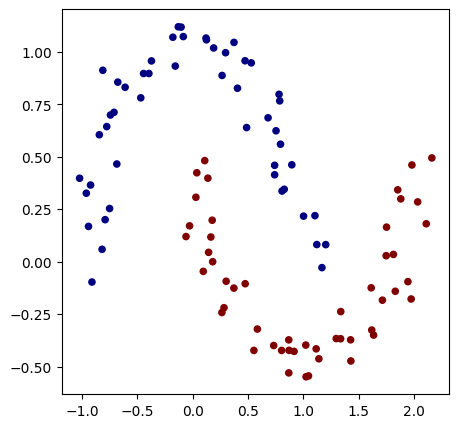

In [ ]:
# ===== 4) 生成并观察数据集 =====

from sklearn.datasets import make_moons, make_blobs

# make_moons: 生成两个月牙形的二分类数据
X, y = make_moons(n_samples=100, noise=0.1)

# 标签从 {0, 1} 映射为 {-1, 1}，便于后续使用 margin loss
y = y * 2 - 1

# 可视化样本分布（先建立“肉眼可分性”的直觉）
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='jet')
plt.title('Training Data (make_moons)')
plt.xlabel('x1')
plt.ylabel('x2')

# 自学任务：
# 1) 把 noise 从 0.1 改为 0.3，观察类别重叠是否加重。
# 2) 记录你对“模型难度”的主观判断，再和训练结果对比。

In [ ]:
# ===== 5) 初始化模型 =====
# 输入维度 2（x1, x2），两个隐藏层各 16 个神经元，输出层 1 个分数
model = MLP(2, [16, 16, 1])

print(model)
print("number of parameters", len(model.parameters()))

# 学习提示：
# - 参数量越多，拟合能力通常越强，但也更容易过拟合或训练不稳。
# - 输出是一个实数 score，后续用 score 的正负来做分类。
# 微练习：把结构改成 [8, 8, 1] 或 [32, 32, 1]，比较训练速度和边界形状。

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [ ]:
# ===== 6) 定义损失函数（含准确率） =====
def loss(batch_size=None):
    # inline DataLoader：若不设 batch_size 就用全量数据
    if batch_size is None:
        Xb, yb = X, y
    else:
        # 随机采样一个小批量（SGD 的基础）
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    # 把每个输入标量都封装为 Value，以便构建计算图
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # 前向传播：得到每个样本的 score
    scores = list(map(model, inputs))

    # max-margin（类似线性 SVM 的 hinge 思路）
    # 当 1 - yi*scorei > 0 时产生惩罚，否则惩罚为 0
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))

    # L2 正则：抑制参数过大，提升泛化稳定性
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))

    total_loss = data_loss + reg_loss

    # 准确率：score > 0 判为 +1，否则判为 -1
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

# 自学任务：
# 1) 把 alpha 改为 0，再观察决策边界是否更“扭曲”。
# 2) 给 loss(batch_size=32) 跑几个 step，体会 mini-batch 噪声。
# 3) 尝试解释：为什么 loss 用 Value，而 accuracy 读 scorei.data？

Value(data=0.8958441028683222, grad=0) 0.5


In [7]:
# ===== 7) 训练循环：前向 -> 反向 -> 参数更新 =====
for k in range(100):
    # 前向计算当前损失和准确率
    total_loss, acc = loss()

    # 梯度清零，避免与上一步梯度累加
    model.zero_grad()

    # 反向传播：沿计算图回传梯度
    total_loss.backward()

    # SGD 更新（这里用了一个从 1.0 线性衰减到 0.1 的学习率）
    learning_rate = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    # 每一步都打印，便于形成对“收敛节奏”的体感
    print(f"step {k:03d} | loss {total_loss.data:.6f} | accuracy {acc * 100:.2f}% | lr {learning_rate:.4f}")

# 自学任务：
# 1) 把学习率固定为 0.1，比较收敛速度与最终精度。
# 2) 只训练 20 步与 300 步，各画一次边界，观察欠拟合/过拟合迹象。
# 3) 当 loss 短暂上升时，不要立刻判断失败，先看长期趋势。

step 0 loss 0.8958441028683222, accuracy 50.0%
step 1 loss 1.723590533697202, accuracy 81.0%
step 2 loss 0.742900631385113, accuracy 77.0%
step 3 loss 0.7705641260584202, accuracy 82.0%
step 4 loss 0.3692793385976538, accuracy 84.0%
step 5 loss 0.313545481918522, accuracy 86.0%
step 6 loss 0.28142343497724337, accuracy 89.0%
step 7 loss 0.2688873331398391, accuracy 91.0%
step 8 loss 0.2567147286057417, accuracy 91.0%
step 9 loss 0.27048625516379227, accuracy 91.0%
step 10 loss 0.24507023853658033, accuracy 91.0%
step 11 loss 0.25099055297915035, accuracy 92.0%
step 12 loss 0.21560951851922944, accuracy 91.0%
step 13 loss 0.23090378446402737, accuracy 93.0%
step 14 loss 0.20152151227899434, accuracy 92.0%
step 15 loss 0.2257450627928223, accuracy 93.0%
step 16 loss 0.19447987596204097, accuracy 92.0%
step 17 loss 0.21089496199246377, accuracy 93.0%
step 18 loss 0.159830773563036, accuracy 94.0%
step 19 loss 0.1845374874688393, accuracy 93.0%
step 20 loss 0.1897752285608763, accuracy 91.

(-1.548639298268643, 1.951360701731357)

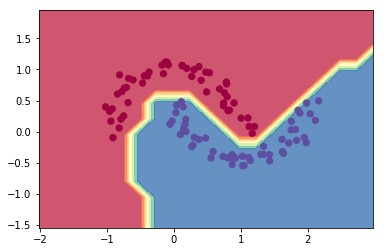

In [ ]:
# ===== 8) 可视化决策边界 =====

# 在平面上铺一张网格，让模型对每个网格点做分类
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h),
)

# 把网格点转换为模型输入格式
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))

# score > 0 判为正类
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors='k', linewidths=0.2)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Decision Boundary After Training')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 自学任务：
# 1) 把 h 改小到 0.05，观察边界更平滑但计算更慢。
# 2) 对比不同模型结构下的边界复杂度，建立“容量-形状”直觉。

## 9) 自学复盘模板（每次实验后填写）

请你每轮训练后写下：

1. 这次我修改了什么？（例如 noise、网络层数、学习率、正则）
2. 训练现象是什么？（loss/accuracy 变化、边界形状变化）
3. 显性知识：我能明确说出的规则是什么？
4. 默会知识：我形成了什么“直觉判断”？
5. 下一个最小实验是什么？（一次只改一个变量）

推荐你的学习循环：
- 预测 -> 执行 -> 对比 -> 复盘 -> 再实验

当你能在运行前大致预判结果时，说明默会知识正在形成。